<a href="https://colab.research.google.com/github/NeoExchangedCorgi/mvp_youtube_shorts_data/blob/main/mvp_youtube_shorts_performance_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP Análise de Dados e Boas Práticas

**Nome:** Gusthavo Silva de Oliveira

**Matrícula:** 4052026000142

**Dataset:** [Youtube Shorts Performance](https://www.kaggle.com/datasets/prince7489/youtube-shorts-performance-dataset?resource=download)

# ***Nota Importante Minha***

Este MVP foi construído com o auxílio de IA *(do próprio Colab inclusive)* com três objetivos: verificar **erros** de sintaxe; simplificar a **codificação**; facilitar a **estilização** do Notebook.

# Descrição do Problema

Análise exploratória do dataset **Youtube Shorts Performance**, buscando padrões e respondendo hipóteses de negócio.

## Hipóteses do Problema

Listando as hipóteses a serem investigadas com base nos dados:

1. **Hipótese 1:** Comedy (category) é a categoria de conteúdo mais assistida.

2. **Hipótese 2:** A duração do vídeo (duration_sec) é diretamente proporcional ao número de comentários (comments).

3. **Hipótese 3:** Lifestyle (category) é categoria de conteúdo mais compartilhado.

## Tipo de Problema

Este é um problema de **análise exploratória (EDA)** com investigação de correlações e distribuições entre variáveis numéricas e categóricas.

## Seleção de Dados

Dataset: **Youtube Shorts Performance**. Fonte: https://www.kaggle.com/datasets/prince7489/youtube-shorts-performance-dataset?resource=download. Arquivo: `youtube_shorts_performance_dataset.csv`. Total de registros: **300**.

## Atributos do Dataset

| Coluna | Tipo | Descrição |
|--------|------|------------|
| video_id | categorical | Identificador único alfanumérico do vídeo na plataforma YouTube |
| title | categorical | O "nome" do vídeo |
| duration_sec | numeric | Tempo de duração de cada vídeo (em segundos) |
| hashtags_count | numeric | Quantidade total de hashtags na descrição ou título do vídeo |
| views | numeric | Quantidade total de visualizações |
| likes | numeric | Quantidade total de curtidas |
| comments | numeric | Quantidade total de comentários (incluindo respostas) |
| shares | numeric | Quantidade total de compartilhamentos |
| upload_hour | numeric | Conta as horas depois que o vídeo foi publicado |
| category | categorical | Gênero do conteúdo |

# Importação das Bibliotecas Necessárias e Carga de Dados

Nesta seção importamos todas as bibliotecas que serão utilizadas ao longo do notebook e carregamos o dataset.

In [8]:
# Bibliotecas de: manipulação de dataframe (pandas), operações numéricas (numpy), gráficos (matplotlib.pyplot e seaborn) e pré-processamento de dados (sklearn).

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

# Configurações de visualização: definindo a estilização (quase um css) dos gráficos
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# --- CARGA DE DADOS (VIA GITHUB) ---
url = 'https://raw.githubusercontent.com/NeoExchangedCorgi/mvp_youtube_shorts_data/refs/heads/main/youtube_shorts_performance_dataset.csv'

# Lendo o dataset diretamente da URL
df = pd.read_csv(url)

# df se refere ao (d)ata(f)rame

print(f"DATASET CARREGADO COM SUCESSO: {df.shape[0]} LINHAS, {df.shape[1]} COLUNAS")
print()
df.head()

DATASET CARREGADO COM SUCESSO: 300 LINHAS, 10 COLUNAS



,video_id,title,duration_sec,hashtags_count,views,likes,comments,shares,upload_hour,category
0,vid_1000,Short Video #0,43,9,198775,21933,3228,400,8,Tech
1,vid_1001,Short Video #1,56,2,290336,20063,3719,1942,16,Comedy
2,vid_1002,Short Video #2,33,6,264206,37032,3228,1817,7,Food
3,vid_1003,Short Video #3,19,9,85076,27269,2371,980,1,Lifestyle
4,vid_1004,Short Video #4,47,8,90780,8041,2891,1109,23,Tech


# Análise de Dados

Nesta etapa realizamos a Análise Exploratória de Dados (EDA) para entender a distribuição, relações e características das variáveis.

## Total e Tipo das Instâncias

In [ ]:
# Cabeçalho: ~~~
# Espaço: print()
print("~~~ DIMENSÕES/SHAPE DO DATASET ~~~")
print()

print(f"LINHAS: {df.shape[0]}, COLUNAS: {df.shape[1]}")
print()

print("~~~ INFORMAÇÕES DAS COLUNAS ~~~")
print()
df.info()
print()

print("~~~ PRIMEIRAS LINHAS ~~~")
print()
df.head()


~~~ DIMENSÕES/SHAPE DO DATASET ~~~

LINHAS: 300, COLUNAS: 10

~~~ INFORMAÇÕES DAS COLUNAS ~~~

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   video_id        300 non-null    object
 1   title           300 non-null    object
 2   duration_sec    300 non-null    int64 
 3   hashtags_count  300 non-null    int64 
 4   views           300 non-null    int64 
 5   likes           300 non-null    int64 
 6   comments        300 non-null    int64 
 7   shares          300 non-null    int64 
 8   upload_hour     300 non-null    int64 
 9   category        300 non-null    object
dtypes: int64(7), object(3)
memory usage: 23.6+ KB

~~~ PRIMEIRAS LINHAS ~~~



,video_id,title,duration_sec,hashtags_count,views,likes,comments,shares,upload_hour,category
0,vid_1000,Short Video #0,43,9,198775,21933,3228,400,8,Tech
1,vid_1001,Short Video #1,56,2,290336,20063,3719,1942,16,Comedy
2,vid_1002,Short Video #2,33,6,264206,37032,3228,1817,7,Food
3,vid_1003,Short Video #3,19,9,85076,27269,2371,980,1,Lifestyle
4,vid_1004,Short Video #4,47,8,90780,8041,2891,1109,23,Tech


## Estatísticas Descritivas

Média

In [ ]:
# Média das variáveis numéricas
# numeric_cols lista os nomes das variáveis numéricas
# means é um resultado da média aritmética efetuado pelo método .mean()

numeric_cols = ['duration_sec', 'hashtags_count', 'views', 'likes', 'comments', 'shares', 'upload_hour']
means = df[numeric_cols].mean()
print("~~~ MÉDIAS ~~~")
print()
print(means.round(2))
# .round(2) para arrendondar os resultados para só duas casas decimais (0.00)

~~~ MÉDIAS ~~~

duration_sec          31.73
hashtags_count         4.34
views             245058.17
likes              23063.13
comments            2638.30
shares               999.58
upload_hour           11.54
dtype: float64


Desvio Padrão

In [ ]:
# Desvio Padrão/Standard Deviation das variáveis numéricas

# Seleciona-se as colunas definidas na lista numeric_cols para se aplicar o método .std(), que calcula o desvio padrão
# O resultado é armazenado na variável std_devs

std_devs = df[numeric_cols].std()
print("~~~ DESVIO PADRÃO ~~~")
print()

print(std_devs.round(2))
print()

# Tabela completa de estatísticas descritivas gerado pelo método .describe() para as colunas numéricas
print("~~~ RESUMO DAS COLUNAS NUMÉRICAS ~~~")
print()
df[numeric_cols].describe().round(2)


~~~ DESVIO PADRÃO ~~~

duration_sec          16.04
hashtags_count         2.96
views             141338.98
likes              14597.46
comments            1416.83
shares               564.41
upload_hour            6.81
dtype: float64

~~~ RESUMO DAS COLUNAS NUMÉRICAS ~~~



,duration_sec,hashtags_count,views,likes,comments,shares,upload_hour
count,300.00,300.00,300.00,300.00,300.00,300.00,300.00
mean,31.73,4.34,245058.17,23063.13,2638.30,999.58,11.54
std,16.04,2.96,141338.98,14597.46,1416.83,564.41,6.81
min,5.00,0.00,1404.00,109.00,40.00,2.00,0.00
25%,18.00,2.00,129620.50,10342.00,1445.75,516.25,6.00
50%,32.00,4.00,255962.00,21779.50,2863.50,988.00,12.00
75%,45.00,7.00,356805.00,36706.50,3761.00,1463.75,17.00
max,59.00,9.00,499401.00,49923.00,4971.00,1998.00,23.00


Histograma

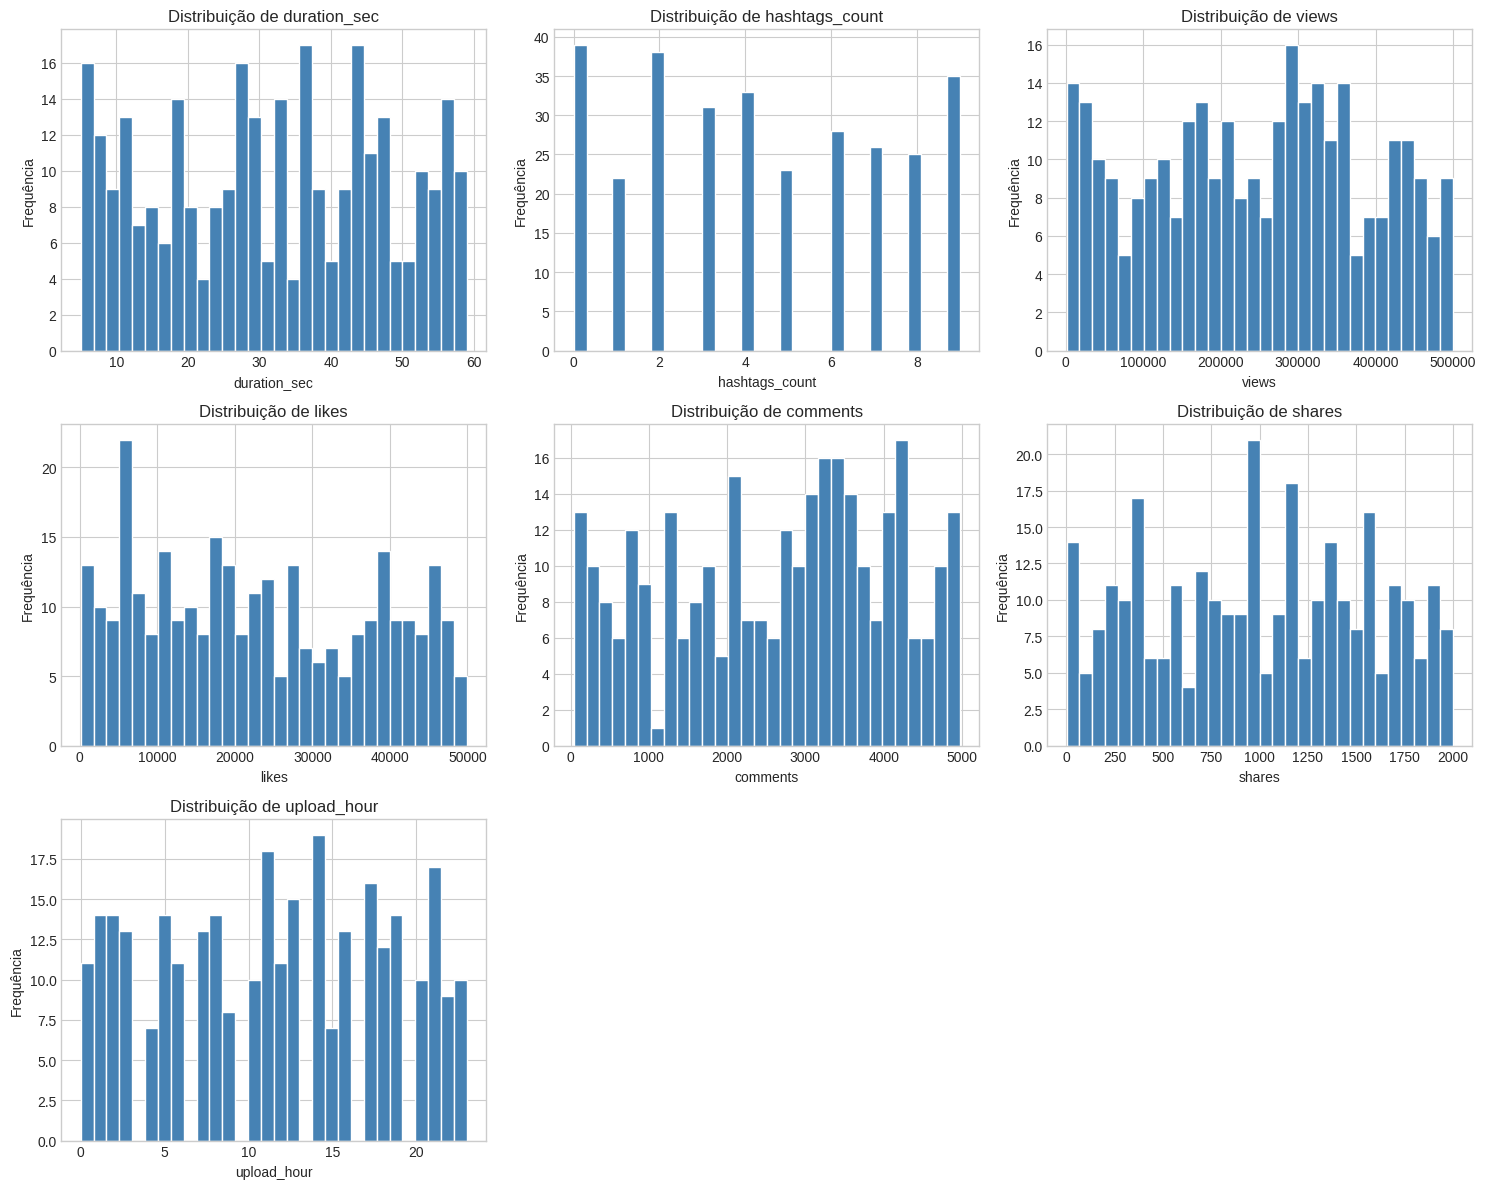

In [ ]:
# Histogramas das variáveis numéricas
# Cria uma figura (fig) e um conjunto de subplots (axes-eixos) para os histogramas
# A disposição da grade (nrows, ncols) é calculada dinamicamente para acomodar todas as colunas numéricas
# figsize define o tamanho total da figura
# Se a imagem parecer pequena, pode-se abri-la numa nova guia ao clicar com o botão direito

fig, axes = plt.subplots(
    nrows=int(np.ceil(len(numeric_cols)/3)), # Número de linhas (row): arredonda para cima o número de colunas dividido por 3
    ncols=min(3, len(numeric_cols)), # Número de colunas (col): máximo de 3 ou o número de colunas numéricas (se for menor)
    figsize=(15, 4 * int(np.ceil(len(numeric_cols)/3))) # Tamanho da figura (largura, altura)
)

# Converte os eixos para um array plano para facilitar a varredura (iteração)
axes = np.array(axes).flatten()

# Itera sobre cada coluna numérica para criar um histograma
for i, col in enumerate(numeric_cols):
    # (axes[i]): cria o histograma no subplot atual
    # df[col].dropna(): seleciona a coluna e remove valores nulos para o plot
    # bins=30: define o número de 'barras' ou intervalos do histograma
    # edgecolor='white': borda branca para cada barra
    # color='steelblue': cor das barras
    axes[i].hist(df[col].dropna(), bins=30, edgecolor='white', color='steelblue')

    # _title define o nome do histograma; _xlabel, o rótulo do eixo x; _ylabel, do eixo y
    axes[i].set_title(f'Distribuição de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequência')

# Se houver mais subplots do que histogramas gerados, serão ocultados os subplots vazios
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

# .tight ajusta o layout para evitar sobreposição de elementos, e .show exibe a figura com todos os histogramas

plt.tight_layout()
plt.show()

Boxplot

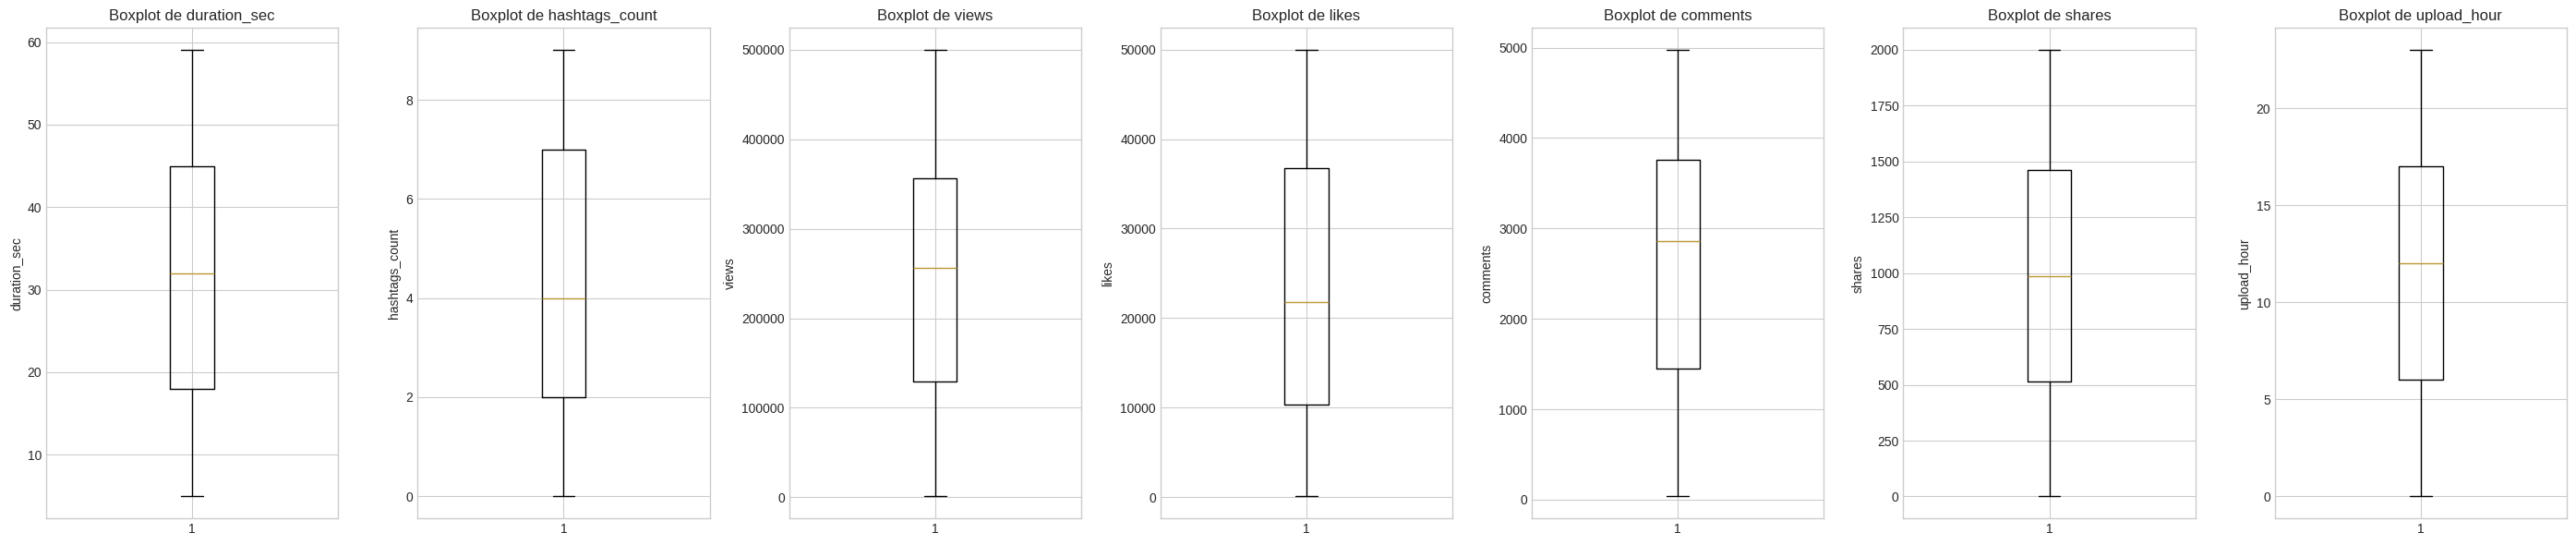

In [ ]:
# Boxplots das variáveis numéricas
# Figura (fig), um conjunto de subplots (axes), nrows=1 (1 linha),
# ncols=len(numeric_cols): número de colunas de gráficos será igual ao número de colunas numéricas,
# figsize=... tamanho total com ajuste para englobar os boxplots
fig, axes = plt.subplots(
    nrows=1,
    ncols=len(numeric_cols),
    figsize=(4 * len(numeric_cols), 6)
)

# Garantir que, se há só 1 coluna, retorna-se 1 objeto axes, não um array
if len(numeric_cols) == 1:
    axes = [axes]

# .boxplot desenha o plano para a coluna atual (col) no eixo correspondente (axes[i])
# dropna() remove valores nulos antes de plotar.
# .set_title nomeia cada boxplot
# .set_ylabel rotula o eixo Y de cada boxplot
for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(f'Boxplot de {col}')
    axes[i].set_ylabel(col)
# .tight ajusta o layout para evitar sobreposição de elementos, e .show exibe a figura com todos os boxplots
plt.tight_layout()
plt.show()

Matriz de Correlação

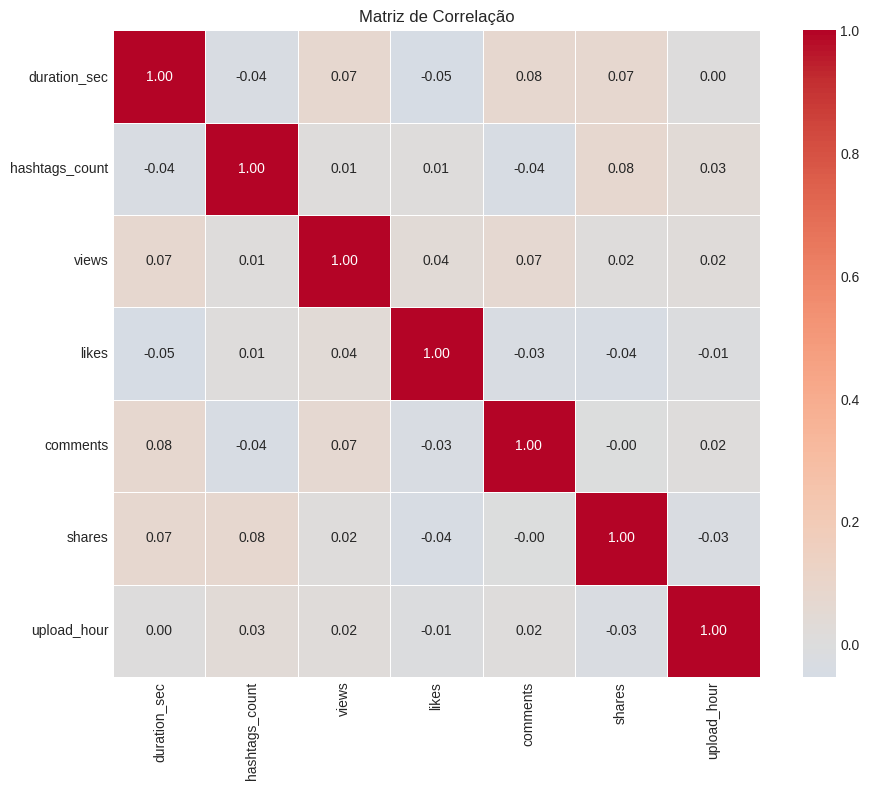

In [ ]:
# Matriz de correlação (corr_matrix)
# O método .corr() aplica-se às colunas numéricas do dataframe e retorna uma tabela onde cada valor representa a correlação entre duas colunas.

corr_matrix = df[numeric_cols].corr()

# Cria uma figura para o gráfico com um tamanho específico.
plt.figure(figsize=(10, 8))

# Gera o heatmap (mapa de calor) com a biblioteca seaborn (sns)
sns.heatmap(
    corr_matrix, # Os dados da matriz de correlação a serem visualizados.
    annot=True, # Define se os valores numéricos das correlações devem ser exibidos nas células do heatmap.
    fmt=".2f", # Formata os valores exibidos para terem duas casas decimais, melhorando a leitura.
    cmap="coolwarm", # Escolhe o mapa de cores 'coolwarm': azul para correlações negativas, vermelho para positivas, branco para zero.
    center=0, # Centraliza o mapa de cores em 0, o que é útil para correlações (positivo vs. negativo).
    square=True, # Garante que as células do heatmap sejam quadradas, mantendo a proporção.
    linewidths=0.5 # Adiciona linhas brancas entre as células, melhorando a separação e clareza.
)

# Define os parâmetros do gráfico heatmap.
plt.title("Matriz de Correlação")
plt.tight_layout()
plt.show()

Tratamento de Valores Nulos

In [ ]:
# Verificação de valores nulos

nulls = df.isnull().sum() # Total de valores nullos (nulls)
null_pct = (nulls / len(df) * 100).round(2) # Porcentagem de valores nulos (nulls_pct), arredondando para 2 casas decimais
null_report = pd.DataFrame({'Nulos': nulls, 'Percentual (%)': null_pct}) # Um DataFrame (null_report) que consolida a contagem e a porcentagem de nulos para cada coluna.

null_report = null_report[null_report['Nulos'] > 0] # Reconhecimento de valores nulos para demonstração

# Confirmando se há, ou não, valores nulos para exibir nas saídas
if null_report.empty:
    print("NENHUM VALOR NULO ENCONTRADO NO DATASET.")
else:
    print("COLUNAS COM VALORES NULOS:")
    print(null_report)
    print()

    # Tratamento: preencher objetos numéricos com mediana, e categóricos (strings) com moda
    for col in df.columns:
        if df[col].isnull().sum() > 0:
            if df[col].dtype in ['float64', 'int64']:
                df[col].fillna(df[col].median(), inplace=True)
                print(f"'{col}' PREENCHIDO COM A MEDIANA: {df[col].median():.2f}")
            else:
                df[col].fillna(df[col].mode()[0], inplace=True)
                print(f"'{col}' PREENCHIDO COM A MODA: {df[col].mode()[0]}")

# Soma total de todos os valores nulos à deriva no dataframe, idealmente 0
print("\nVALORES NULOS APÓS TRATAMENTO:", df.isnull().sum().sum())


NENHUM VALOR NULO ENCONTRADO NO DATASET.

VALORES NULOS APÓS TRATAMENTO: 0


# Pré-Processamento de Dados

Normalização

In [ ]:
# Normalização com MinMaxScaler (escala os valores numéricos do df para um intervalo entre 0 a 1)
scaler_mm = MinMaxScaler()
df_normalized = df.copy() # cria uma cópia do dataframe original
df_normalized[numeric_cols] = scaler_mm.fit_transform(df[numeric_cols]) # aplica a normalização para transformar os dados até o intervalo

print("~~~ DADOS NORMALIZADOS (MinMaxScaler) ~~~")
print()
print(df_normalized[numeric_cols].describe().round(3)) # dados normalizados para as colunas numéricas em 3 casas decimais
df_normalized[numeric_cols].head()


~~~ DADOS NORMALIZADOS (MinMaxScaler) ~~~

       duration_sec  hashtags_count    views    likes  comments   shares  \
count       300.000         300.000  300.000  300.000   300.000  300.000   
mean          0.495           0.483    0.489    0.461     0.527    0.500   
std           0.297           0.329    0.284    0.293     0.287    0.283   
min           0.000           0.000    0.000    0.000     0.000    0.000   
25%           0.241           0.222    0.257    0.205     0.285    0.258   
50%           0.500           0.444    0.511    0.435     0.573    0.494   
75%           0.741           0.778    0.714    0.735     0.755    0.732   
max           1.000           1.000    1.000    1.000     1.000    1.000   

       upload_hour  
count      300.000  
mean         0.502  
std          0.296  
min          0.000  
25%          0.261  
50%          0.522  
75%          0.739  
max          1.000  


,duration_sec,hashtags_count,views,likes,comments,shares,upload_hour
0,0.703704,1.000000,0.396330,0.438110,0.646522,0.199399,0.347826
1,0.944444,0.222222,0.580188,0.400570,0.746096,0.971944,0.695652
2,0.518519,0.666667,0.527718,0.741217,0.646522,0.909319,0.304348
3,0.259259,1.000000,0.168017,0.545228,0.472724,0.489980,0.043478
4,0.777778,0.888889,0.179471,0.159232,0.578179,0.554609,1.000000


Padronização

In [ ]:
# Padronização com StandardScaler
# Quase a mesma lógica da normalização, mas transforma os dados de cada coluna para que a média e o desvio tenham valores 0 e 1
scaler_std = StandardScaler()
df_standardized = df.copy()
df_standardized[numeric_cols] = scaler_std.fit_transform(df[numeric_cols])

print("~~~ DADOS PADRONIZADOS (StandardScaler) ~~~")
print()
print(df_standardized[numeric_cols].describe().round(3)) # dados padronizados para as colunas numéricas em 3 casas decimais
df_standardized[numeric_cols].head()


~~~ DADOS PADRONIZADOS (StandardScaler) ~~~

       duration_sec  hashtags_count    views    likes  comments   shares  \
count       300.000         300.000  300.000  300.000   300.000  300.000   
mean         -0.000          -0.000    0.000   -0.000     0.000   -0.000   
std           1.002           1.002    1.002    1.002     1.002    1.002   
min          -1.669          -1.472   -1.727   -1.575    -1.837   -1.770   
25%          -0.857          -0.794   -0.818   -0.873    -0.843   -0.858   
50%           0.017          -0.116    0.077   -0.088     0.159   -0.021   
75%           0.829           0.900    0.792    0.936     0.794    0.824   
max           1.703           1.578    1.803    1.843     1.649    1.772   

       upload_hour  
count      300.000  
mean         0.000  
std          1.002  
min         -1.697  
25%         -0.815  
50%          0.067  
75%          0.802  
max          1.684  


,duration_sec,hashtags_count,views,likes,comments,shares,upload_hour
0,0.703665,1.577659,-0.328009,-0.077549,0.416909,-1.064082,-0.520845
1,1.515345,-0.793911,0.320884,-0.205867,0.764037,1.672539,0.655099
2,0.079295,0.561272,0.135701,0.958538,0.416909,1.450699,-0.667838
3,-0.794823,1.577659,-1.133795,0.288605,-0.188974,-0.034743,-1.549796
4,0.953413,1.238863,-1.093371,-1.030811,0.178657,0.194196,1.684049


PCA

VARIÂNCIA EXPLICADA POR CADA COMPONENTE: [0.168 0.156]

VARIÂNCIA ACUMULADA: 0.324



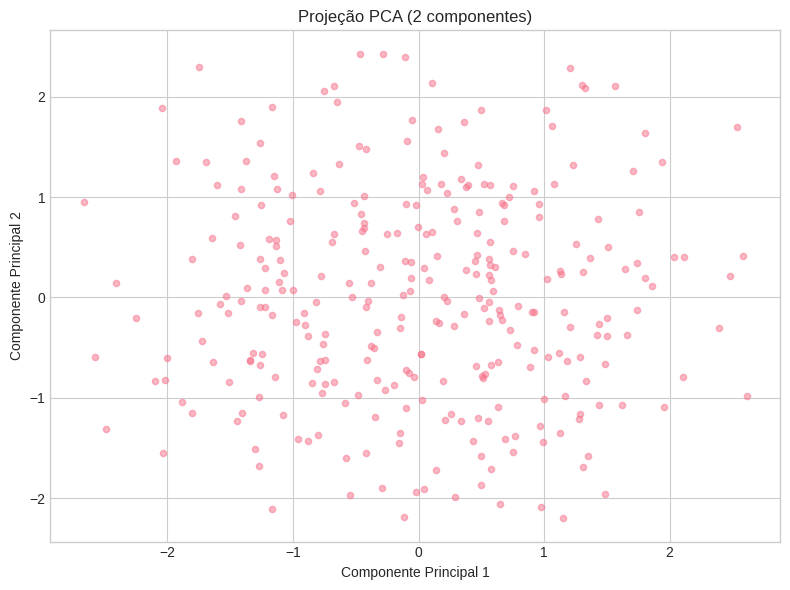

In [ ]:
# Redução de Dimensionalidade com PCA
# Define o número de componentes principais a serem extraídos (mínimo de 2 ou o total de colunas numéricas)
n_components = min(2, len(numeric_cols))
# Inicializa o objeto PCA com o número de componentes definidos
pca = PCA(n_components=n_components)
# Aplica o PCA aos dados padronizados e armazena os componentes
components = pca.fit_transform(df_standardized[numeric_cols])

# Exibe a variância explicada por cada componente principal
print(f"VARIÂNCIA EXPLICADA POR CADA COMPONENTE: {pca.explained_variance_ratio_.round(3)}")
print()
# Exibe a variância acumulada pelos componentes principais
print(f"VARIÂNCIA ACUMULADA: {pca.explained_variance_ratio_.sum():.3f}")
print()

# Se houver pelo menos 2 componentes, cria um gráfico de dispersão da projeção PCA
if n_components >= 2:
    fig, ax = plt.subplots(figsize=(8, 6))
    # Imprime os dados projetados nos dois primeiros componentes principais
    ax.scatter(components[:, 0], components[:, 1], alpha=0.5, s=20)
    ax.set_xlabel('Componente Principal 1')
    ax.set_ylabel('Componente Principal 2')
    ax.set_title('Projeção PCA (2 componentes)')
    plt.tight_layout()
    plt.show()


# Respondendo nossas hipóteses

## Hipótese 1

~~~ HIPÓTESE 1 ~~~

 = Comedy (category) é a categoria de conteúdo mais assistida. = 

Ranking de 'views' por 'category':

category
Lifestyle    277479.95
Comedy       271887.96
Travel       246886.05
Food         234776.95
Education    224513.25
Tech         223569.09
Name: views, dtype: float64



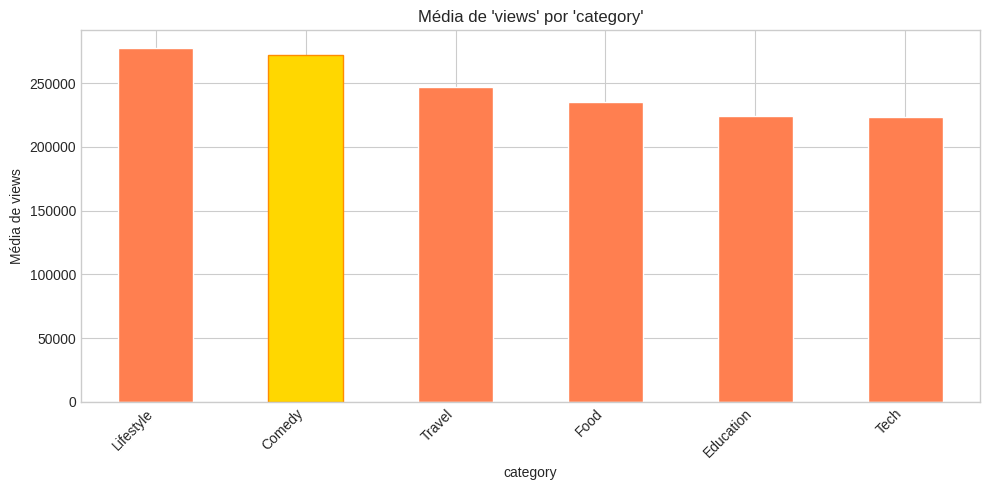


Categoria 'Comedy': média = 271887.96 (posição 2/6)

NÃO CONFIRMADO: A categoria com maior 'views' é 'Lifestyle' (277479.95).


In [ ]:
# Verificando a primeira hipótese
print("~~~ HIPÓTESE 1 ~~~")
print()
print(" = Comedy (category) é a categoria de conteúdo mais assistida. = ")
print()

# Verifica se 'Comedy' é o valor com maior média de 'views'
group_means = df.groupby('category')['views'].mean().sort_values(ascending=False)
print(f"Ranking de 'views' por 'category':")
print()
print(group_means.round(2))
print()

# Monta e exibe o gráfico de coluna e eixo com barras em dourado (para comédia) e laranja (para o restante das categorias)
fig, ax = plt.subplots(figsize=(10, 5))
group_means.plot(kind='bar', ax=ax, color='coral', edgecolor='white')
if 'Comedy' in group_means.index:
    bar_idx = list(group_means.index).index('Comedy')
    ax.patches[bar_idx].set_facecolor('gold')
    ax.patches[bar_idx].set_edgecolor('darkorange')
ax.set_title(f"Média de 'views' por 'category'")
ax.set_xlabel('category')
ax.set_ylabel('Média de views')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

top_cat = group_means.idxmax()
top_val = group_means.max()
if 'Comedy' in group_means.index:
    val_specific = group_means['Comedy']
    rank = list(group_means.index).index('Comedy') + 1
    print(f"\nCategoria 'Comedy': média = {val_specific:.2f} (posição {rank}/{len(group_means)})")
    if top_cat == 'Comedy':
        print(f"CONFIRMADO: 'Comedy' é a categoria com maior 'views'.")
    else:
        print()
        print(f"NÃO CONFIRMADO: A categoria com maior 'views' é '{top_cat}' ({top_val:.2f}).")
else:
    print(f"Nota: valor 'Comedy' não encontrado na coluna 'category'.")

    print(f"Categoria líder: {top_cat} ({top_val:.2f})")


## Hipótese 2

~~~ HIPÓTESE 2 ~~~

 = A duração do vídeo (duration_sec) é diretamente proporcional ao número de comentários (comments). =

Correlação de Pearson entre 'duration_sec' e 'comments': 0.0787



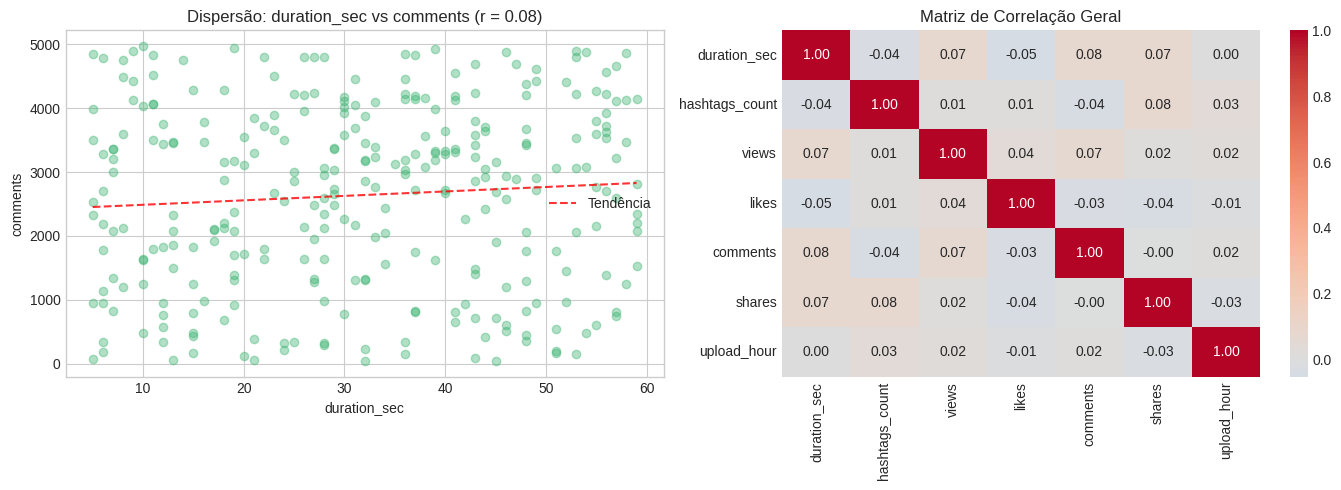


Conclusão: Correlação fraca e positiva (r = 0.08).

A hipótese NÃO é fortemente suportada pelos dados (correlação fraca).


In [ ]:
# Verificando a segunda hipótese
print("~~~ HIPÓTESE 2 ~~~")
print()
print(" = A duração do vídeo (duration_sec) é diretamente proporcional ao número de comentários (comments). =")
print()

# Correlação entre 'duration_sec' e 'comments' usando o método de Pearson
corr = df['duration_sec'].corr(df['comments'])
print(f"Correlação de Pearson entre 'duration_sec' e 'comments': {corr:.4f}")
print()

# Cria uma figura com dois subplots para os gráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Imprime o gráfico de dispersão entre 'duration_sec' e 'comments'
axes[0].scatter(df['duration_sec'], df['comments'], alpha=0.4, color='mediumseagreen')
axes[0].set_xlabel('duration_sec')
axes[0].set_ylabel('comments')
axes[0].set_title(f"Dispersão: duration_sec vs comments (r = {corr:.2f})")

# Linha de tendência para o gráfico de dispersão
import numpy as np
# Cria uma máscara para ignorar valores nulos ao calcular a linha de tendência
mask = df['duration_sec'].notna() & df['comments'].notna()
# Calcula os coeficientes da linha de regressão linear (grau 1)
z = np.polyfit(df.loc[mask, 'duration_sec'], df.loc[mask, 'comments'], 1)
# Cria uma função polinomial a partir dos coeficientes
p = np.poly1d(z)
# Gera pontos para a linha de tendência dentro do intervalo de 'duration_sec'
x_line = np.linspace(df['duration_sec'].min(), df['duration_sec'].max(), 100)
# Plota a linha de tendência
axes[0].plot(x_line, p(x_line), "r--", alpha=0.8, label=f"Tendência")
axes[0].legend()

# Calcula a matriz de correlação para todas as colunas numéricas
corr_matrix = df[[col for col in df.select_dtypes(include='number').columns]].corr()
# Gera um heatmap da matriz de correlação no segundo subplot
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[1])
axes[1].set_title("Matriz de Correlação Geral")
plt.tight_layout()
plt.show()

# Avalia a força e direção da correlação para concluir sobre a hipótese
if abs(corr) > 0.7:
    strength = "forte"
elif abs(corr) > 0.4:
    strength = "moderada"
else:
    strength = "fraca"
direction = "positiva" if corr > 0 else "negativa"
print(f"\nConclusão: Correlação {strength} e {direction} (r = {corr:.2f}).")
if abs(corr) > 0.4:
    print("A hipótese é SUPORTADA pelos dados.")
else:
    print()
    print("A hipótese NÃO é fortemente suportada pelos dados (correlação fraca).")

# Se a correlação for maior que 0.7, forte; se estiver entre 0.41 e 0.7, moderada; se menor que 0.4, fraca


## Hipótese 3

~~~ HIPÓTESE 3 ~~~

Lifestyle (category) é categoria de conteúdo mais compartilhado.

Ranking de 'shares' por 'category':

category
Comedy       1134.21
Education    1013.55
Tech          992.84
Travel        987.20
Lifestyle     966.52
Food          900.95
Name: shares, dtype: float64



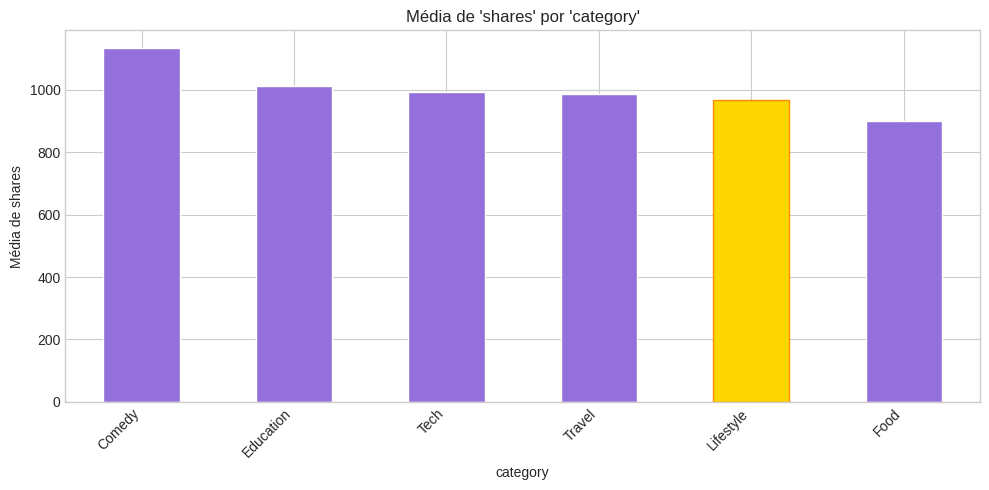


Categoria 'Lifestyle': média = 966.52 (posição 5/6)

NÃO CONFIRMADO: A categoria com maior 'shares' é 'Comedy' (1134.21).


In [ ]:
# Verificando a terceira hipótese
print("~~~ HIPÓTESE 3 ~~~")
print()
print("Lifestyle (category) é categoria de conteúdo mais compartilhado.")
print()

# Verificar se 'Lifestyle' é o valor com maior média de 'shares'
group_means = df.groupby('category')['shares'].mean().sort_values(ascending=False)
print(f"Ranking de 'shares' por 'category':")
print()
print(group_means.round(2))
print()

# Cria um gráfico de barras para visualizar a média de compartilhamentos por categoria.
fig, ax = plt.subplots(figsize=(10, 5))
group_means.plot(kind='bar', ax=ax, color='mediumpurple', edgecolor='white')
# Caracteriza o Lifestyle, se estiver presente, com a cor dourada em sua barra.
if 'Lifestyle' in group_means.index:
    bar_idx = list(group_means.index).index('Lifestyle')
    ax.patches[bar_idx].set_facecolor('gold')
    ax.patches[bar_idx].set_edgecolor('darkorange')
ax.set_title(f"Média de 'shares' por 'category'")
ax.set_xlabel('category')
ax.set_ylabel('Média de shares')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Analisa os resultados para confirmar ou refutar a hipótese, verificando qual a categoria com a maior média de views, o máximo de shares, retornando um rank de posição.
top_cat = group_means.idxmax()
top_val = group_means.max()
if 'Lifestyle' in group_means.index:
    val_specific = group_means['Lifestyle']
    rank = list(group_means.index).index('Lifestyle') + 1
    print(f"\nCategoria 'Lifestyle': média = {val_specific:.2f} (posição {rank}/{len(group_means)})")
    if top_cat == 'Lifestyle':
        print(f"CONFIRMADO: 'Lifestyle' é a categoria com maior 'shares'.")
    else:
        print()
        print(f"NÃO CONFIRMADO: A categoria com maior 'shares' é '{top_cat}' ({top_val:.2f}).")
else:
    print()
    print(f"Nota: valor 'Lifestyle' não encontrado na coluna 'category'.")
    print(f"Categoria líder: {top_cat} ({top_val:.2f})")


# Conclusão

## Sumário da Análise

Este projeto realizou uma análise exploratória completa do dataset **Youtube Shorts Performance**, contendo 300 registros com 10 atributos (7 numéricos e 3 categóricos).

## Hipóteses Investigadas

- **Hipótese 1**: *Comedy (category) é a categoria de conteúdo mais assistida:* Investigada por meio de análise de correlação e visualizações de dispersão. Os resultados REFUTAM a hipótese, demonstrando que Lifestyle é a categoria mais assistida.

- **Hipótese 2**: *A duração do vídeo (duration_sec) é diretamente proporcional ao número de comentários (comments):* Analisada através de comparação de médias por grupo e visualizações de barras. A correlação é FRACA, o que torna a hipótese pouco sustentada pelos resultados.

- **Hipótese 3**: *Lifestyle (category) é categoria de conteúdo mais compartilhado:* Explorada com análise multivariada e correlações entre múltiplas dimensões do dataset. A hipótese foi REFUTADA; os resultados mostram que Comedy é a categoria mais compartilhada.

## Principais Achados

- O pré-processamento revelou a distribuição e qualidade dos dados disponíveis.
- As estatísticas descritivas forneceram uma base sólida para a compreensão do dataset.
- A matriz de correlação evidenciou relações entre as variáveis numéricas.
- As visualizações (histogramas, boxplots) mostraram a distribuição e presença de valores atípicos (outliers).
